## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [1]:
# Installing the libraries with the specified version.
# !pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

# This has been updated with info found in the discussion forum replies on a question from Biao Song on 11/4/25.

# !pip install pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 xgboost==3.1.3 -q --user

# !pip install imblearn -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# Library to split data
from sklearn.model_selection import train_test_split

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# For working with dates
import datetime

# For any file and system related task
import os

## Import Dataset

In [3]:
# Reading the data from csv file and assigning it to a DataFrame .

original_data = pd.read_csv('EasyVisa.csv')

# Creating a work copy of the Dataframe.

df = original_data.copy()

## Overview of the Dataset

* Sanity Check.
* Observations.

#### View the first and last 5 rows of the dataset

In [4]:
# Looking at the first 5 rows.
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
df.tail() #last 5 rows.

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


* The dataset has been loaded properly and columns are as described in Data Description.

#### Understand the shape of the dataset

In [6]:
df.shape

(25480, 12)

* The dataset has 25480 rows and 12 columns.

#### Check the data types of the columns for the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


* There are no null values in the dataset. All columns except Number of employees, year of establishment and prevailing wage are object data types.
* Target variable case_status is object data type.

#### Checking for duplicate values

In [8]:
df.duplicated().sum()

np.int64(0)

* There are no duplicate values in the dataset.

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Case id has all unique values. This column could be droped as it provides no value to the analysis or model.
* There are 6 continents in the dataset, whith Asia as the most common one (16861).
* There are 4 values on education of the employee, with Bachelo's as most common (10234).
* 14802 have job experience.
* 22525 don'trequire job training.
* Number of employees has negative values.
* Employer's companies were established between 1800 and 2016.
* There are 5 regions of employment, the mos common is Northeast (7195).
* The average prevailing wage is 74455.81. The min is 2.1367 and max is 319210.27, and it could be due to scales in unit_of_wage(by hour, by week, by month, by year).
* There are 4 units of wage, with Year the most common (22962).
* 22773 workers have a full time position.
* 17018 visas were certified, 8462 were denied.

#### Fixing the negative values in number of employees columns

In [10]:
# Checking shape of dataframe with only negative values.
df.loc[df["no_of_employees"] < 0].shape 

(33, 12)

* There are 33 negative values in the table. These could be considered as data entry errors and will be corrected by using their absolute values.

In [11]:
# Changing the values in number of employees to absolute values.
df["no_of_employees"] = abs(df["no_of_employees"])

#### Let's check the count of each unique category in each of the categorical variables

In [12]:
# Making a list of all categorical variables.
cat_col = list(df.select_dtypes("object").columns)

# Printing number of count of each unique value in each column.
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 50)

case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

* Case_id has 25480 unique values, and will be dropped.
* Most employees hold Bachelor degree, and Doctorate is the least common.
* Th most common wage unit is Year, followed by Hourl, Week and Month.

In [13]:
# Checking that 'case_id' has all unique values.
df.case_id.nunique()

25480

In [14]:
#Dropping case_id column because it is not significant for training the model.
df.drop(["case_id"], axis=1, inplace=True)

### Univariate Analysis

In [15]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on continent

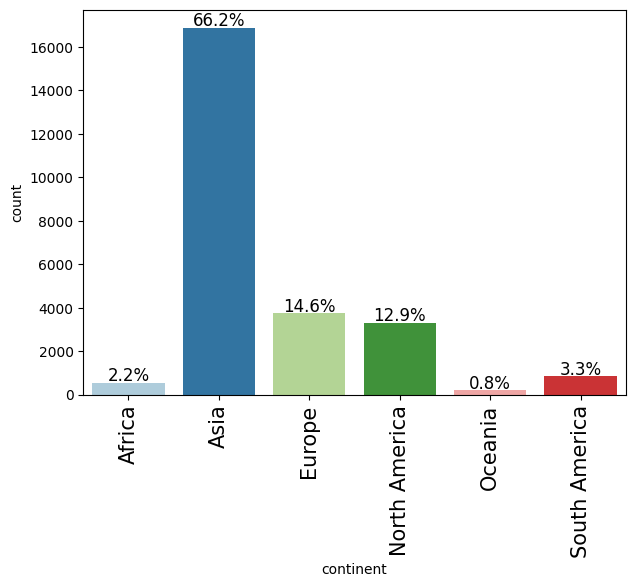

In [17]:
labeled_barplot(df, "continent", perc=True)

* Asia has the largest number of potential employees.
* Oceania is the least.

#### Observations on education of employee

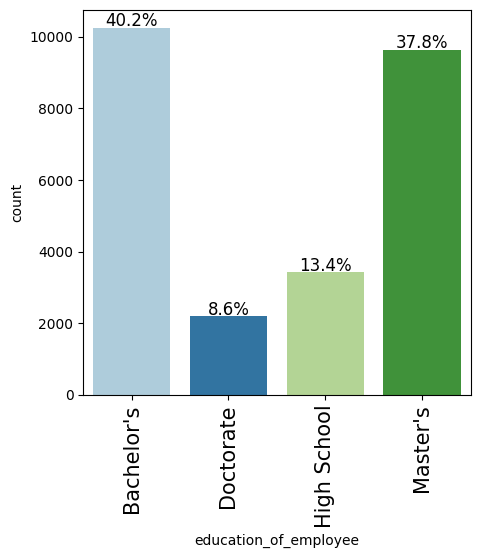

In [18]:
labeled_barplot(df, "education_of_employee", perc=True)

* Predominance of Bachelor's and Master's degree holders (78%).
* Doctorate represent the smallest.

#### Observations on job experience

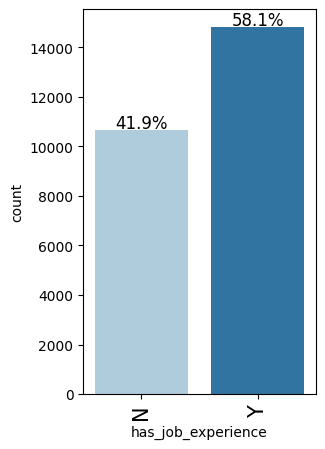

In [19]:
labeled_barplot(df, "has_job_experience", perc=True)

* 58.1% have some job experience, while 41.9% don't.

#### Observations on on job training

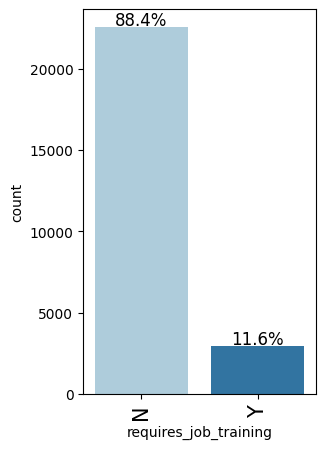

In [20]:
labeled_barplot(df, "requires_job_training", perc=True)

* 88.4% doesn't require job training, while 11.6% require job training.

#### Observations on number of employees

In [21]:
# Statistical summary of the column.

df['no_of_employees'].describe()

count     25480.000000
mean       5667.089207
std       22877.917453
min          11.000000
25%        1022.000000
50%        2109.000000
75%        3504.000000
max      602069.000000
Name: no_of_employees, dtype: float64

* There is a wide range of values from 11 to 602069, and a high std of 22877.

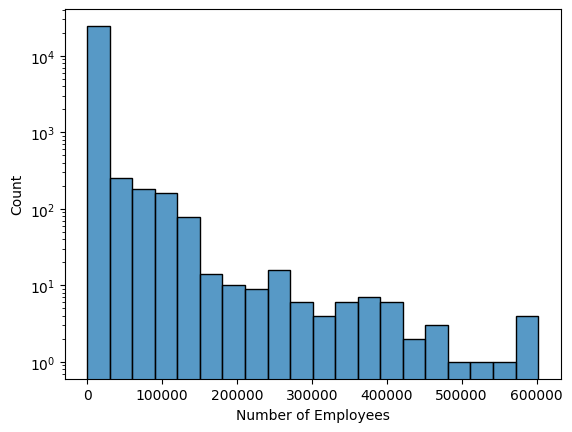

In [22]:
# Plotting a histogram with 20 bins for better viewing and setting y axis to logarithmic scale for visibility of small values.

sns.histplot(df['no_of_employees'], bins=20)
plt.yscale('log')
plt.xlabel('Number of Employees');

* Right skewed distribution with mean > median, with 75% of the companies with less than 3505 employees.

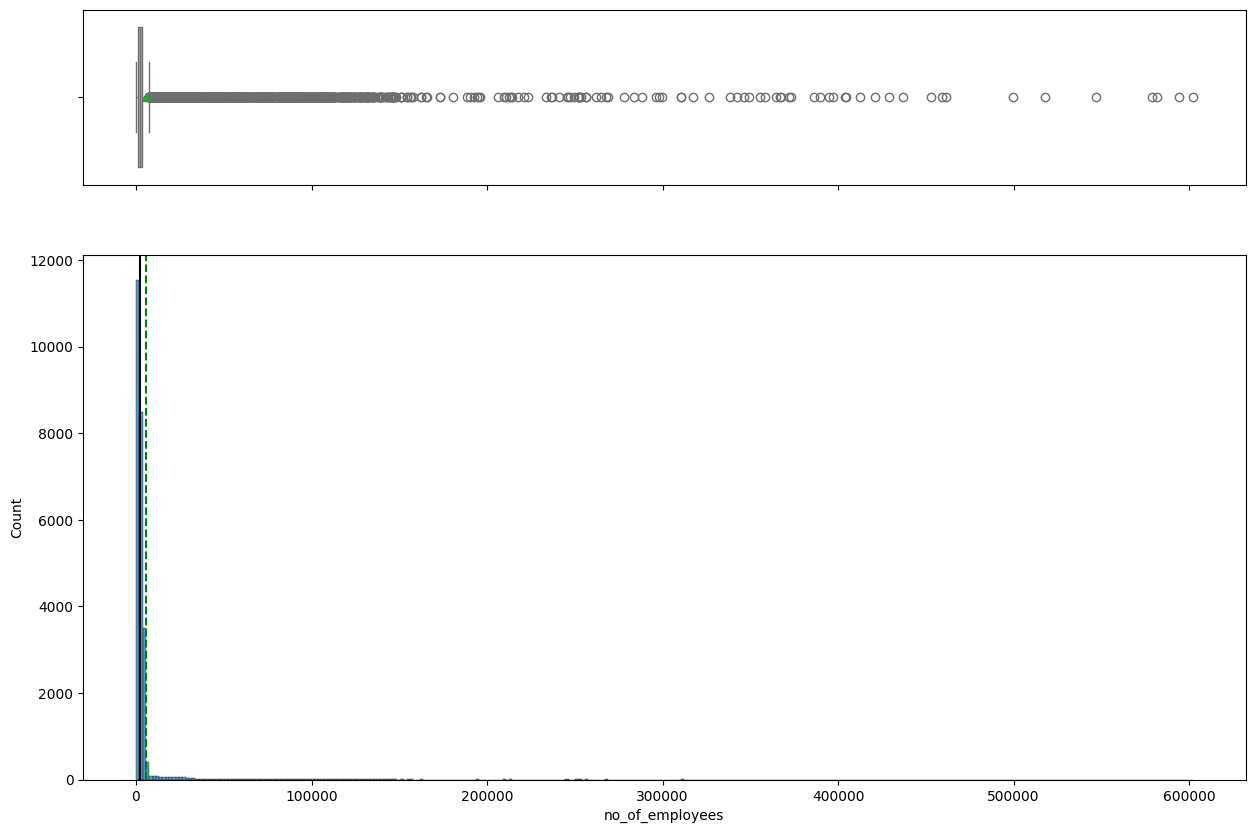

In [23]:
histogram_boxplot(df,'no_of_employees')

* Boxplot shows great amount of outliers.

#### Observations on year of establishment

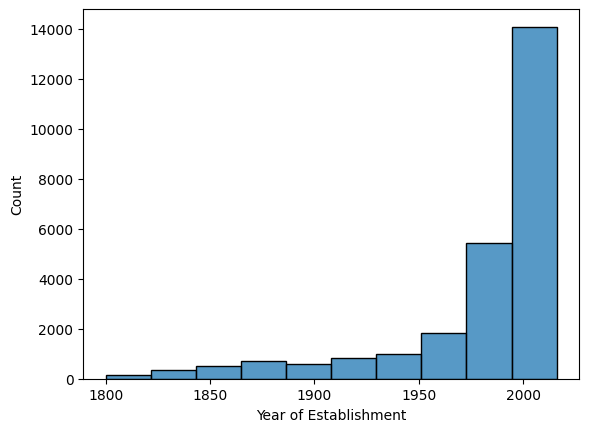

In [24]:
sns.histplot(df['yr_of_estab'], bins=10)
plt.xlabel('Year of Establishment');

* Left skewed distribution.
* Most of the companies were established around and after the year 2000.

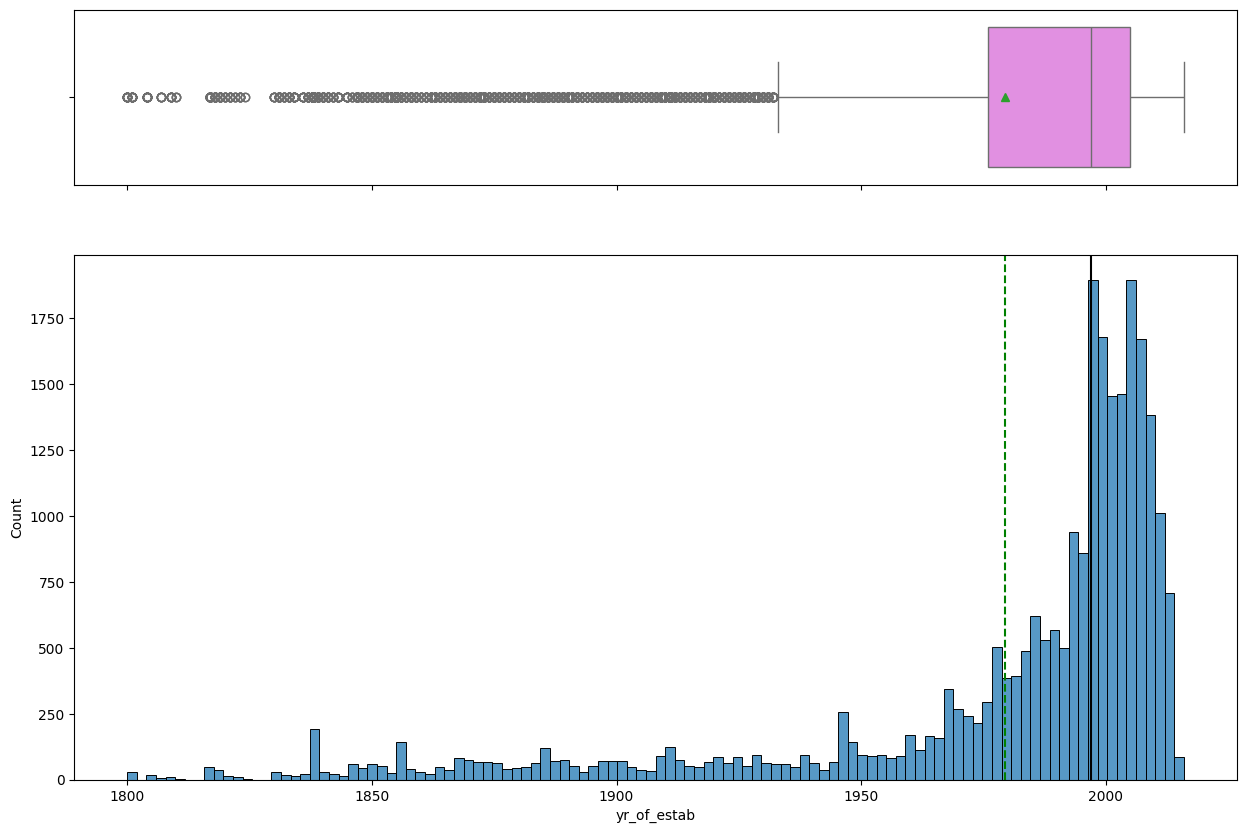

In [25]:
histogram_boxplot(df, 'yr_of_estab')

* Several outliers in the lower whisker.

#### Observations on region of employment

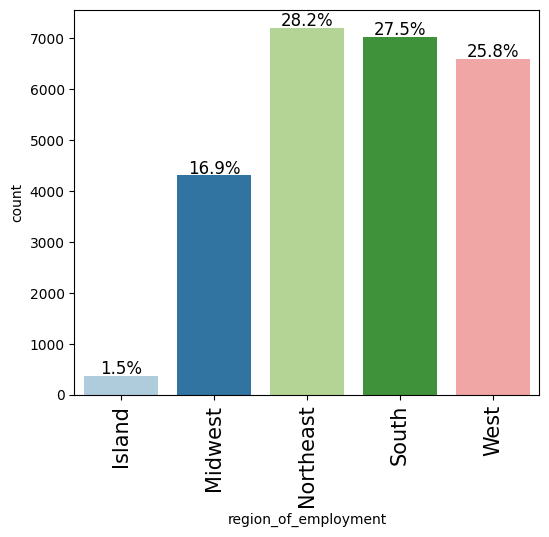

In [26]:
labeled_barplot(df, "region_of_employment", perc=True)


* Most intended region of employment is Northeast, followed by South and West.
* Island is the least.

#### Observations on prevailing wage

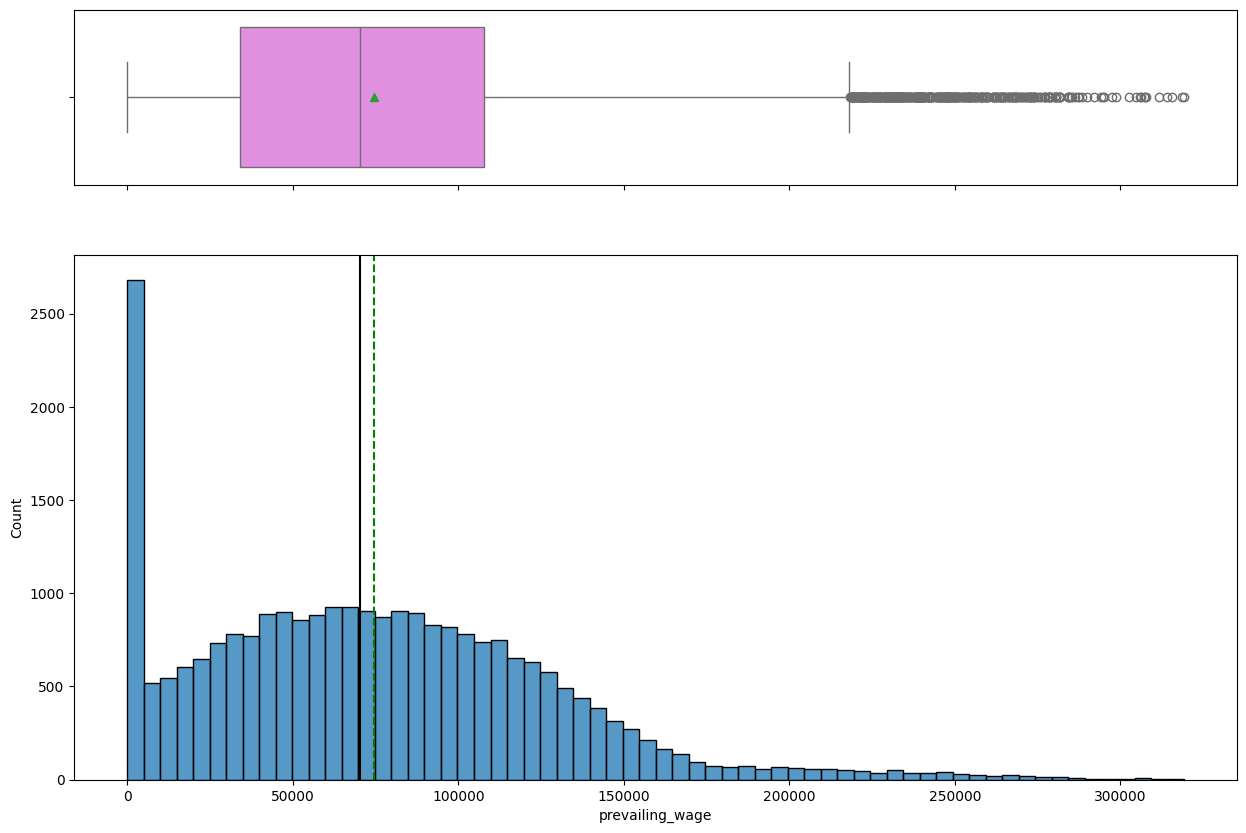

In [27]:
histogram_boxplot(df, 'prevailing_wage')

* Right skewed distribution with outliers on the higher end. 
* There could be a relationship with the 'unit_of_wage' variable.

#### Observations on unit of wage

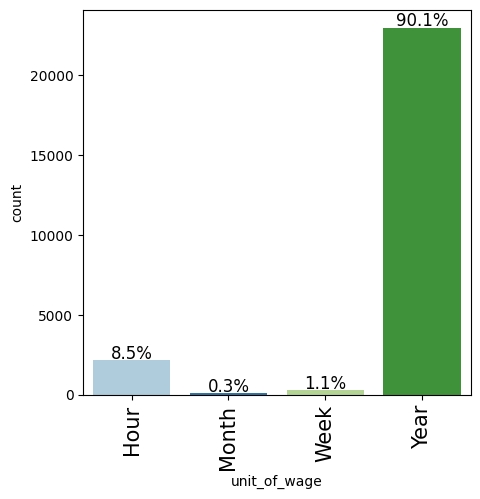

In [28]:
labeled_barplot(df, "unit_of_wage", perc=True)

* The prevailing wage most common is Year, and least commonly Month.

#### Observations on type of position

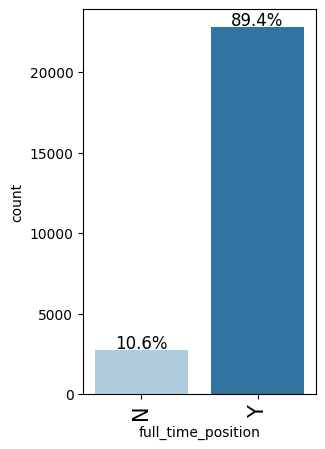

In [29]:
labeled_barplot(df, "full_time_position", perc=True)

* 89.4% candidates are intended for full-time position, while 10.6% are considered for part-time position.

#### Observations on case status

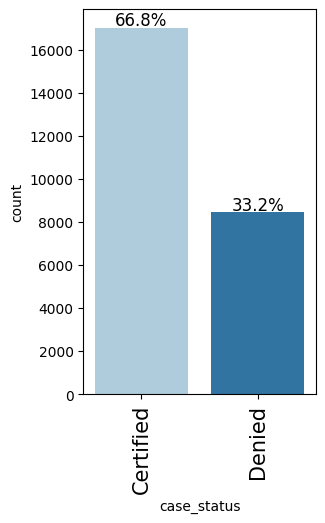

In [30]:
labeled_barplot(df, "case_status", perc=True)

* 66.8% of the applications were Certified, while 33.2% were Denied.
* There is a low unbalance in favor of the Certified value, and is expected models will be biased towards this category.

### Bivariate Analysis

#### Correlation Check

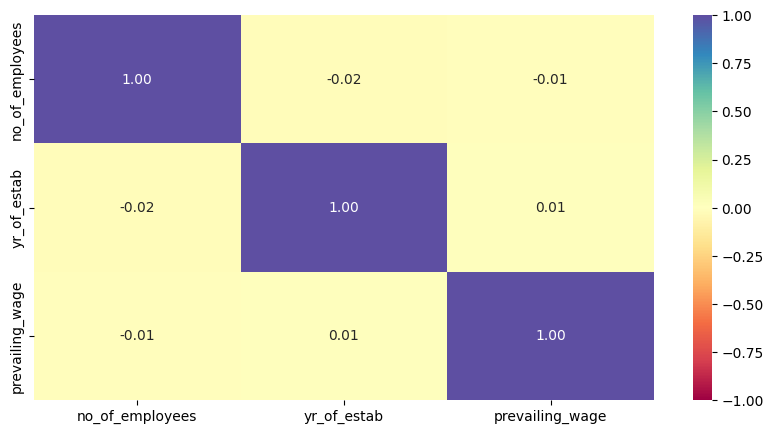

In [31]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

* There is no significant correlation between the numerical variables.

**Creating functions that will help us with further analysis.**

In [32]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [33]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


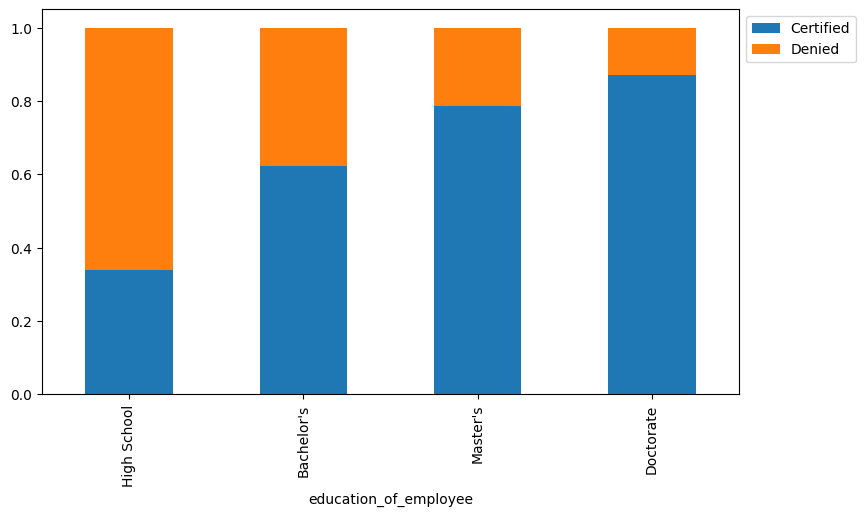

In [34]:
stacked_barplot(df, "education_of_employee", "case_status")

* Doctorate has the highest certification rate(87.2%) and the lowest denial rate (12.8%) followed by Master (78.1% certified and 21.4% denied).
* High School has the lowest certification rate (34%) and the highest denial rate(66%).
* Higher education level enhances an applicant's chances for certification.


#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


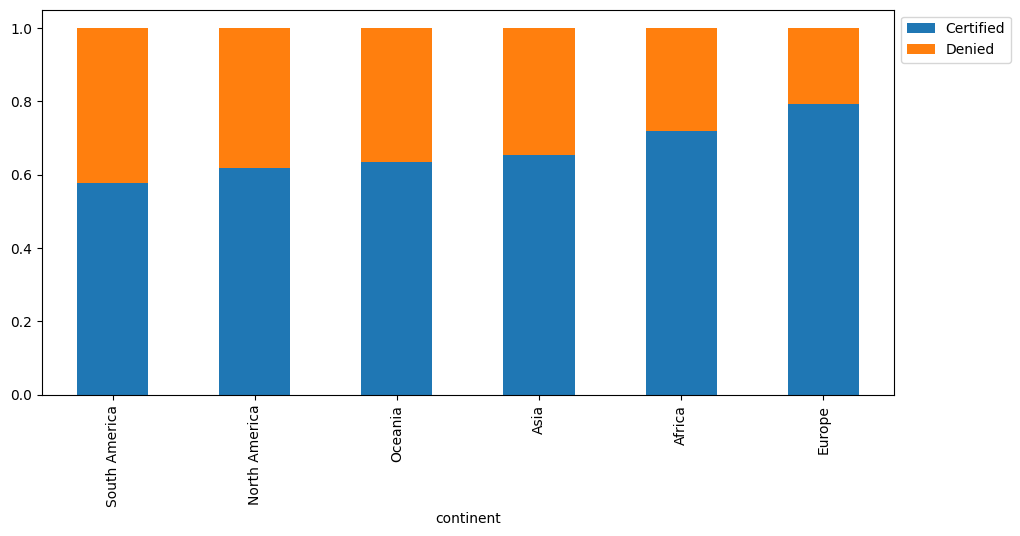

In [35]:
stacked_barplot(df, "continent", "case_status")

* Europe has the highest certification rate (79.3%) and lower denial rate (20.7%), followed by Africa (72.0% & 28.0%).
* South America has the lowest certification rate (57.7%) and highest denial rate (42.3%).
* Asia has the highest number of applicants (16861), while Oceania has the lowest (192).

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


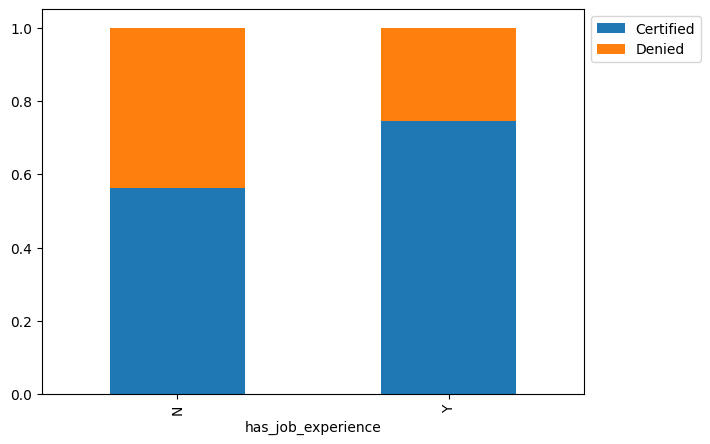

In [36]:
stacked_barplot(df, "has_job_experience", "case_status")

* Job experience has a higher certification rate (74.4%) than no job experience(56.1%).

#### Is the prevailing wage consistent across all regions of the US?

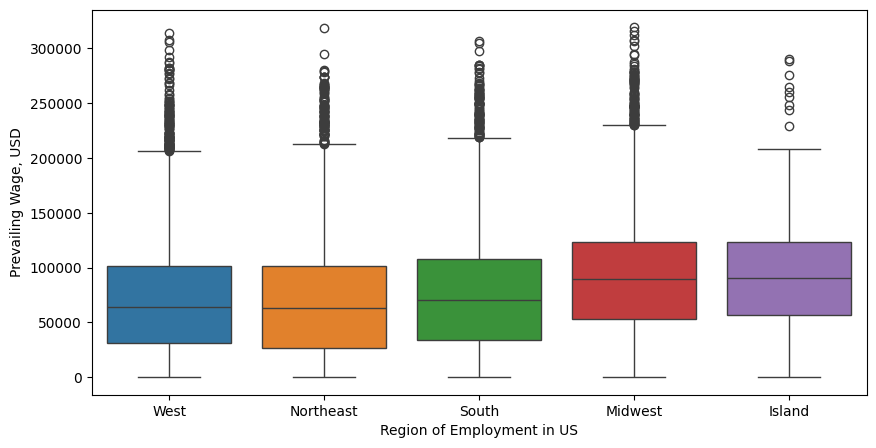

In [37]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="region_of_employment", y="prevailing_wage", hue='region_of_employment')
plt.ylabel('Prevailing Wage, USD')
plt.xlabel('Region of Employment in US');

* West, Northeast and South regions show a similar wage distribution, with wages marginally higher for Midwest and Island.
* All boxplots show outliers in the high whiskers.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

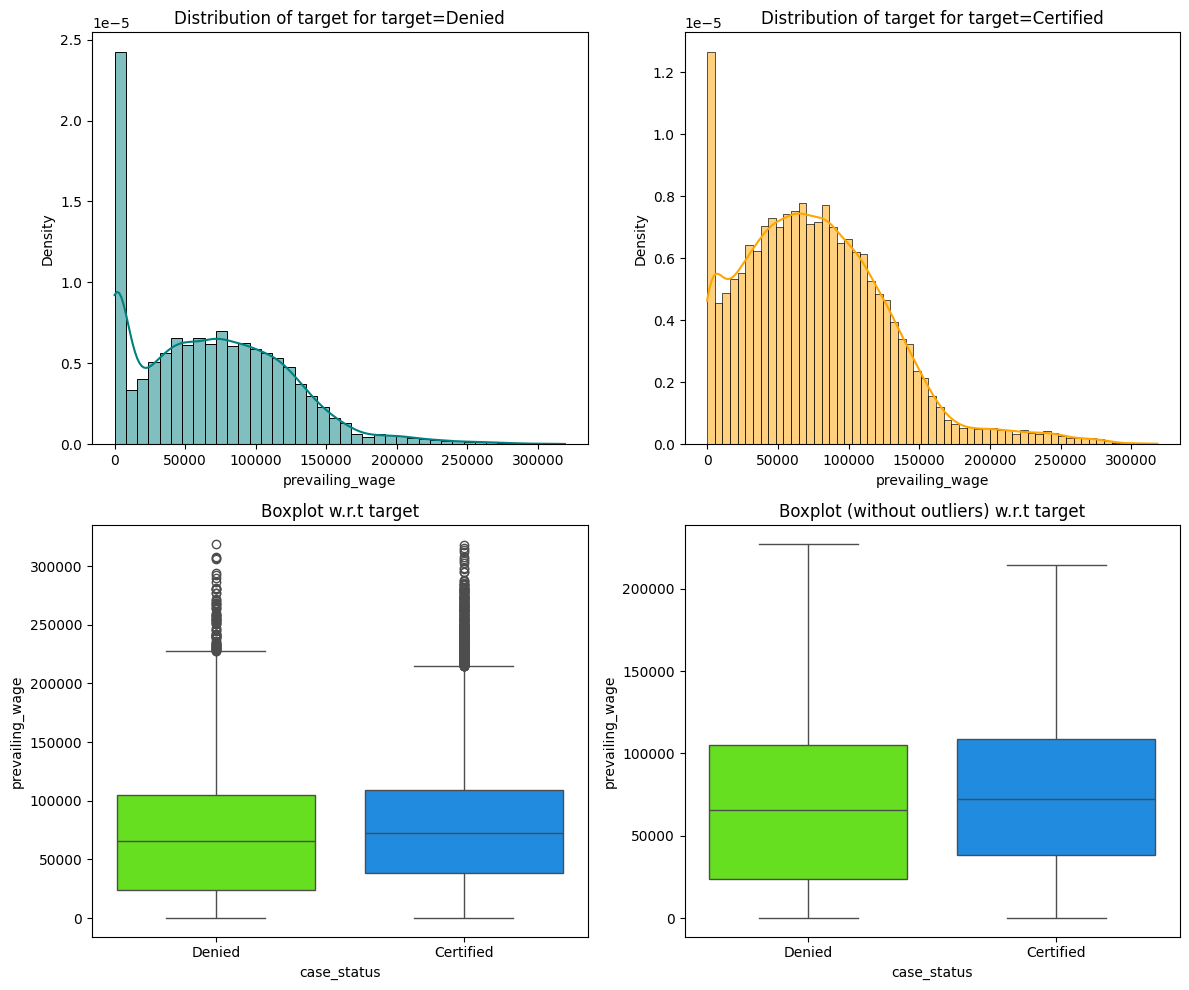

In [38]:
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

* The distribution and boxplot show that the median for prevailing wage is slightly higher for the cases that are certified.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


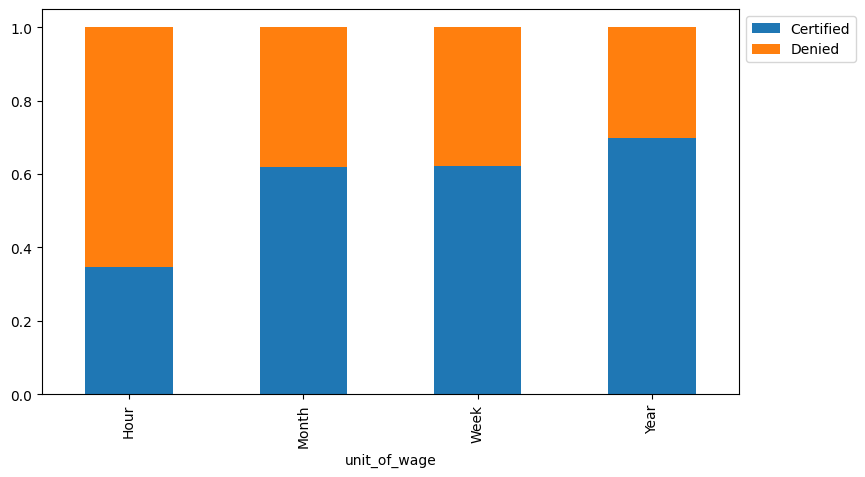

In [39]:
stacked_barplot(df, "unit_of_wage", "case_status")

* Year has the highest certification rate (69.9%).
* Hour has the highest denial rate (65.4%).
* Reporting wages as Year base could increase chances for certification.

## Data Pre-processing

### Outlier Check

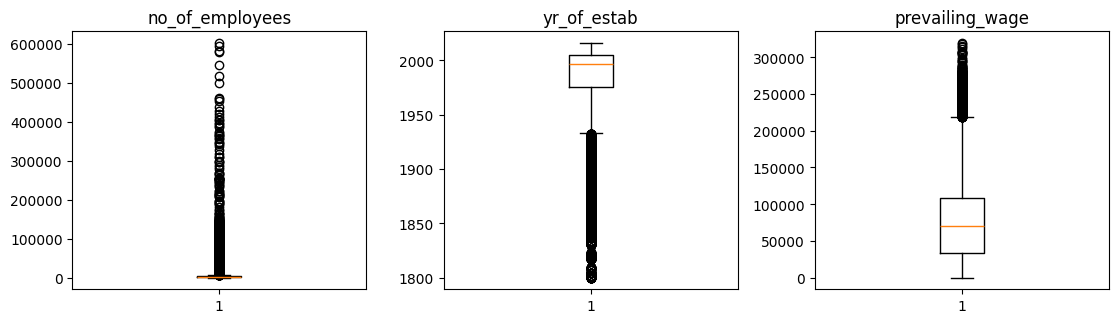

In [40]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* There are outliers in all numerical columns of the dataset.
* They will not be adjusted here as is expected to perform normalization to help in logistic regression analysis.
* Year of Establishment will be converted to years of operation to flip the distribution.

### Data Preparation for modeling

In [41]:
# Converting the 'Year of Establishment' column to 'Years of Operation'.

# Getting the current year
current_year = datetime.datetime.now().year

# Subtract current year from the yr_of_estab column, create new column 'yrs_of_oper' and drop the old column

df['yrs_of_oper'] = (current_year - df['yr_of_estab'])

df = df.drop(['yr_of_estab'], axis=1)

In [42]:
# Encoding categorical variables.

df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

In [43]:
# Defining an Education of Employee dictionary for value replacement.

ed_of_emp_dict = {"High School":'0', "Bachelor's":'1',"Master's":'2',"Doctorate":'3'}

df['education_of_employee'] = df['education_of_employee'].map(lambda x: ed_of_emp_dict[x])


In [44]:
df["has_job_experience"] = df["has_job_experience"].apply(lambda x: 1 if x == "Y" else 0)

df["requires_job_training"] = df["requires_job_training"].apply(lambda x: 1 if x == "Y" else 0)

df["full_time_position"] = df["full_time_position"].apply(lambda x: 1 if x == "Y" else 0)

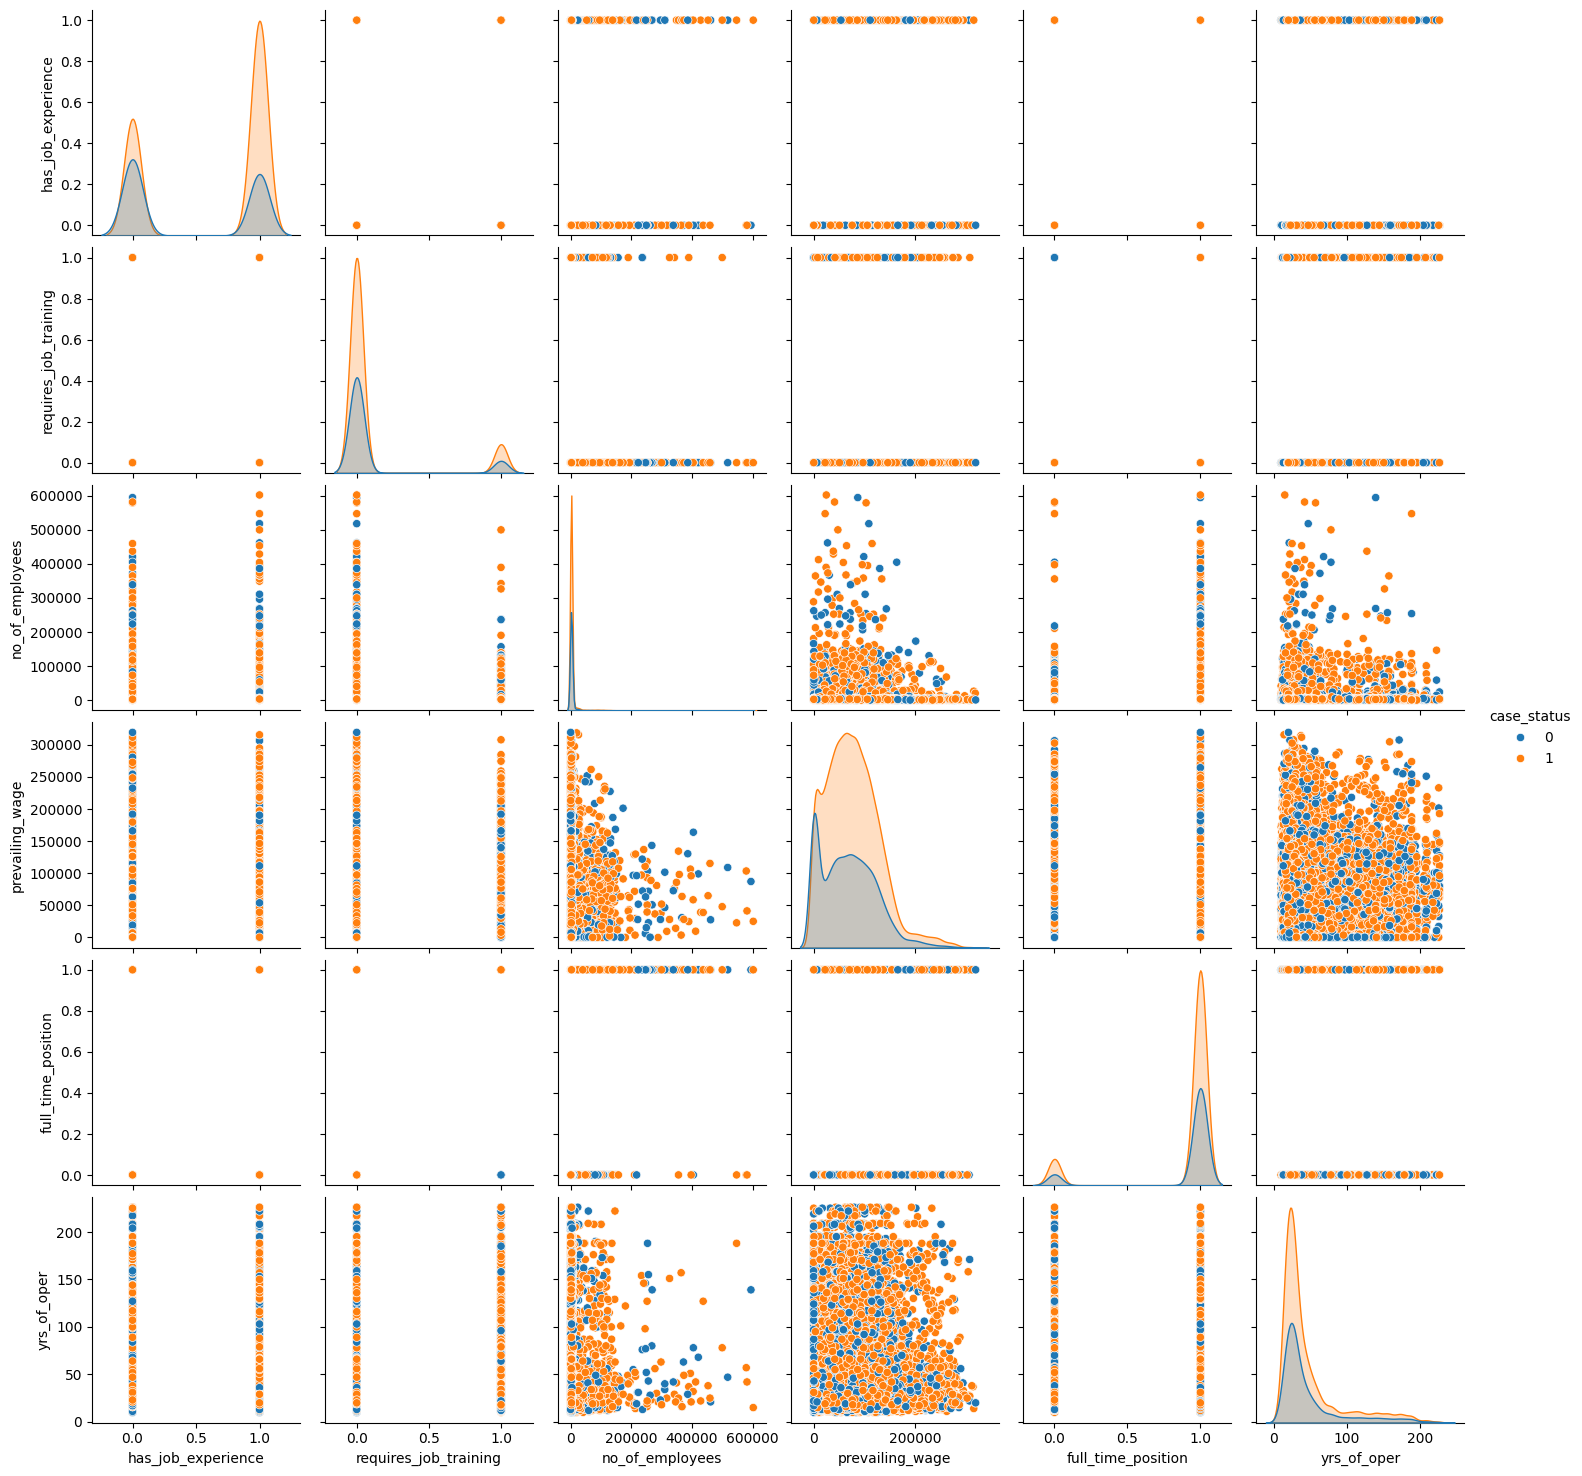

In [45]:
# Quick check to visually identify if there are any strong predictors.

sns.pairplot(df, hue='case_status');

* There are no strong predictors that can be identified.

In [46]:
# Initialize sklearn one hot encoder (prefered over get_dummies)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first').set_output(transform='pandas')


In [47]:
X = df.drop(["case_status"], axis=1)
Y = df["case_status"]

cat_en = encoder.fit_transform(X[["continent", "region_of_employment",'unit_of_wage']])

X= pd.concat([X, cat_en], axis=1).drop(columns=["continent", "region_of_employment",'unit_of_wage'])

X = X.astype(float)

In [48]:
X.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
education_of_employee,25480.0,1.415934,0.826718,0.0000,1.00,1.00,2.0000,3.00
has_job_experience,25480.0,0.580926,0.493417,0.0000,0.00,1.00,1.0000,1.00
requires_job_training,25480.0,0.115973,0.320199,0.0000,0.00,0.00,0.0000,1.00
no_of_employees,25480.0,5667.089207,22877.917453,11.0000,1022.00,2109.00,3504.0000,602069.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
full_time_position,25480.0,0.893760,0.308151,0.0000,1.00,1.00,1.0000,1.00
yrs_of_oper,25480.0,46.590071,42.366929,10.0000,21.00,29.00,50.0000,226.00
continent_Asia,25480.0,0.661735,0.473129,0.0000,0.00,1.00,1.0000,1.00
continent_Europe,25480.0,0.146468,0.353582,0.0000,0.00,0.00,0.0000,1.00
continent_North America,25480.0,0.129199,0.335427,0.0000,0.00,0.00,0.0000,1.00


* After hot encoding, the following variables were dropped: Hour (unit_of_wage), Island (region_of_employment) and Africa (continent).

In [49]:
# Splitting data into training and validation set with a ratio of 7:3:
X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

#Test data and valid with a ratio of 9:1
X_val,X_test,y_val,y_test = train_test_split(
    X_val,y_val,test_size=0.1,random_state=1,stratify=y_val
)

In [50]:
# Normalizing (Standardize) the numerical variables with zscore from scipy, to prevent data leakage.

# features = ['no_of_employees', 'prevailing_wage', 'yrs_of_oper']

# X_train[features] = X_train[features].apply(zscore)

# X_val[features] = X_val[features].apply(zscore)

# X_test[features] = X_test[features].apply(zscore)

In [51]:
# Normalizing the numerical variables with StandardScaler, after split to prevent data leakage.

scaler=StandardScaler()

features = ['no_of_employees', 'prevailing_wage', 'yrs_of_oper']

X_train[features] = scaler.fit_transform(X_train[features])

X_val[features] = scaler.transform(X_val[features])

X_test[features] = scaler.transform(X_test[features])

In [52]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 19)
Shape of Validation set :  (6879, 19)
Shape of test set :  (765, 19)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

**Model Objective:**
* A classification model that facilitates the process of visa approvals.

* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

**Model's possible wrong predictions (confusion matrix):**

*  Predicts applicant should be Denied, but in reality has all qualifications to be certified **(FN)**.

*  Predicts applicant will get Certified, but in reality does not have the necessary qualifications to be certified **(FP)**.

**Impact of wrong predictions:**

*  For False Negatives (FN) — If qualified candidates are denied, the companies will lose suitable candidates for the positions.

*  For False Positives (FP) — If unqualified candidates get certification, it means that qualified US workers will lose opportunities for employment.

**Model Focus:**

* As both type of errors have significant consequences for the organization's objectives (attraction of qualified external workers and protection of local workforce), F1 score should be used to provide a balanced evaluation of both errors.

* As F1 score is maximized, the model is expected to make correct classifications predictions with a balance between Precision and Recall.

**General Model:**

*  For this project the best in the following list of classification models will be used: Logistic Regression, Decision Tree, Bagging with Logistic Regression estimator, Bagging (default DT), Random Forest, AdaBoost, GBM and XGBoost.


First, let's create a functions to calculate different metrics so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification` function will be used to check the model performance of models.


In [53]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [54]:
#Creates a custom scorer using the F1 score to evaluate model performance.

scorer = metrics.make_scorer(metrics.f1_score)

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [55]:
models = []  # Empty list to store all the models

models.append(("Logistic Regression", LogisticRegression(random_state=1))) # adding logistic regression model to list
models.append(("Bagging wt LR", BaggingClassifier(LogisticRegression(), random_state=1))) # adding bagging with logistic regression model to list
models.append(("Bagging", BaggingClassifier(random_state=1)))# adding bagging model to list
models.append(("Random forest", RandomForestClassifier(random_state=1)))# adding random forest model to list
models.append(("GBM", GradientBoostingClassifier(random_state=1)))# adding gradient boosting model to list
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))# adding adaboost model
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))# adding xgboost model
models.append(("dtree", DecisionTreeClassifier(random_state=1))) #adding decision tree classifier model

results1 = []  # Empty list to store all cross-validation scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score on training dataset
print("\n" "Cross-Validation performance on training dataset with original data:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1 # defining 5 fold stratified cross-validation
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring = scorer,cv=kfold
    ) #perform cross-validation and get F1 score
    results1.append(cv_result)# append result to list
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

#loop through each model to train and evaluate it on validation dataset
for name, model in models:
    model.fit(X_train, y_train)#train model on training data
    scores = f1_score(y_val, model.predict(X_val)) #calculate F1 score on validation data
    print("{}: {}".format(name, scores)) #print F1 score for each model


Cross-Validation performance on training dataset with original data:

Logistic Regression: 0.8168111638256127
Bagging wt LR: 0.8165863516879736
Bagging: 0.77684862747662
Random forest: 0.8037516010348614
GBM: 0.8240516342865922
Adaboost: 0.818984983587154
Xgboost: 0.8099121148845138
dtree: 0.7399368280979695

Validation Performance:

Logistic Regression: 0.8134067033516759
Bagging wt LR: 0.813444033209963
Bagging: 0.7702540617162795
Random forest: 0.8017905475744327
GBM: 0.8210461914958703
Adaboost: 0.8154911206983044
Xgboost: 0.8059824651882413
dtree: 0.7498904949627683


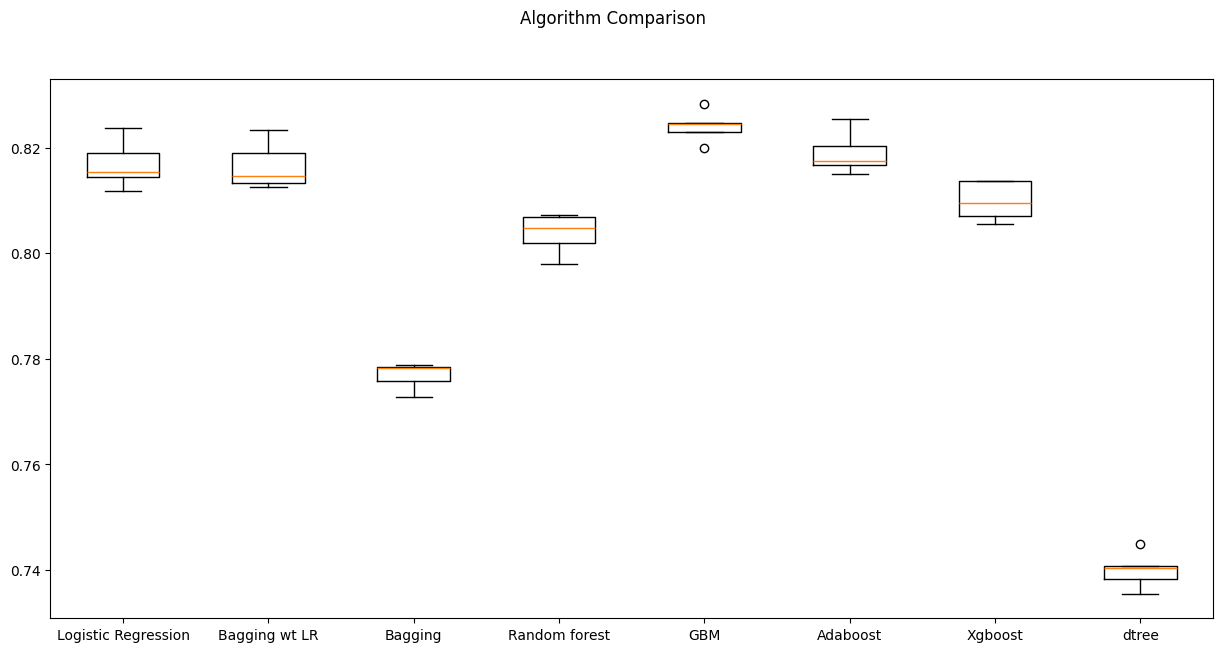

In [56]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(15, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

* GBM is the best model at this point, due to having the highest F1 score on training and validation sets,  and good generalization (a 0.01 or 1% difference between training and validation).

* Adaboost is also a good model with the second high F1 score on both sets, and a difference of 0.003 or 0.3%.

* Logistic Regression and Bagging with Logistic Regression estimator are the next good models with similar third and fourth highest F1 scores and 0.003 differences between sets.


### Model Building with Oversampled data

In [57]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 19)
After OverSampling, the shape of train_y: (23826,) 



In [58]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic Regression (o)", LogisticRegression(random_state=1))) # adding logistic regression model to list
models.append(("Bagging wt LR (o)", BaggingClassifier(LogisticRegression(), random_state=1))) # adding bagging with logistic regression to list
models.append(("Bagging (o)", BaggingClassifier(random_state=1)))# adding bagging model to list
models.append(("Random forest (o)", RandomForestClassifier(random_state=1)))# adding random forest model to list
models.append(("GBM (o)", GradientBoostingClassifier(random_state=1)))# adding gradient boosting model to list
models.append(("Adaboost (o)", AdaBoostClassifier(random_state=1)))# adding adaboost model
models.append(("Xgboost (o)", XGBClassifier(random_state=1, eval_metric="logloss")))# adding xgboost model
models.append(("dtree (o)", DecisionTreeClassifier(random_state=1))) #adding decision tree classifier model

results2 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with oversampled data:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over,scoring = scorer, cv=kfold
    )
    results2.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset with oversampled data:

Logistic Regression (o): 0.6866029628700515
Bagging wt LR (o): 0.685854099716698
Bagging (o): 0.7358621004199349
Random forest (o): 0.7762676076115186
GBM (o): 0.7416062939025065
Adaboost (o): 0.7085404265137011
Xgboost (o): 0.766915721204123
dtree (o): 0.7043520959833259

Validation Performance:

Logistic Regression (o): 0.7285956827552753
Bagging wt LR (o): 0.7262773722627737
Bagging (o): 0.7352601156069364
Random forest (o): 0.7758430681066785
GBM (o): 0.7716373601278831
Adaboost (o): 0.7603438395415473
Xgboost (o): 0.7790122098779012
dtree (o): 0.7355068432179815


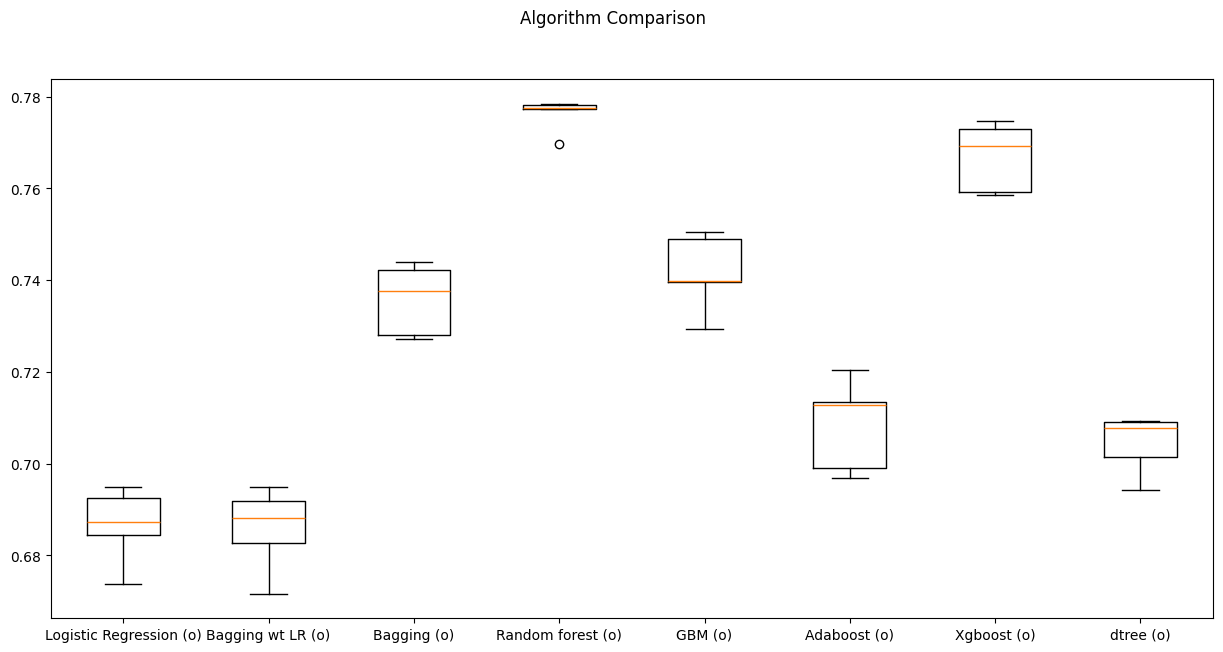

In [59]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(15, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results2)
ax.set_xticklabels(names)

plt.show()

* Every model's performance has dropped significantly, compared to using original data. Probably caused by the unbalanced class being the mayority class and lack of strong predictors.

* On this set Random Forest has the highest perfomance with good generalization on the validation set (difference between training and validation of 0.011 or 1.1%).

* As the dataset is more balanced, Logistic Regression, Bagging with Logistic Regression, GBM, Xgboost, dtree and Adaboost show better performance and generalization on the validation datase, with Adaboost being the most significant (5% increase).


### Model Building with Undersampled data

In [60]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 19)
After UnderSampling, the shape of train_y: (11846,) 



In [61]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Logistic Regression (u)", LogisticRegression(random_state=1))) # adding logistic regression model to list
models.append(("Bagging wt LR (u)", BaggingClassifier(LogisticRegression(), random_state=1))) # adding bagging with logistic regression to list
models.append(("Bagging (u)", BaggingClassifier(random_state=1)))# adding bagging model to list
models.append(("Random forest (u)", RandomForestClassifier(random_state=1)))# adding random forest model to list
models.append(("GBM (u)", GradientBoostingClassifier(random_state=1)))# adding gradient boosting model to list
models.append(("Adaboost (u)", AdaBoostClassifier(random_state=1)))# adding adaboost model
models.append(("Xgboost (u)", XGBClassifier(random_state=1, eval_metric="logloss")))# adding xgboost model
models.append(("dtree (u)", DecisionTreeClassifier(random_state=1))) #adding decision tree classifier model

results3 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with undersampled data:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un,scoring = scorer, cv=kfold,n_jobs =-1
    )
    results3.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset with undersampled data:

Logistic Regression (u): 0.6858100752815852
Bagging wt LR (u): 0.6839476244971211
Bagging (u): 0.6497314051341743
Random forest (u): 0.6879880238853647
GBM (u): 0.7102342329579733
Adaboost (u): 0.6958864827074176
Xgboost (u): 0.6883024074687917
dtree (u): 0.628898244945554

Validation Performance:

Logistic Regression (u): 0.7413690120654641
Bagging wt LR (u): 0.7412804586717631
Bagging (u): 0.6873365707881958
Random forest (u): 0.7315035799522673
GBM (u): 0.7576398683591914
Adaboost (u): 0.7589316684009713
Xgboost (u): 0.7428706661933498
dtree (u): 0.6866387058118634


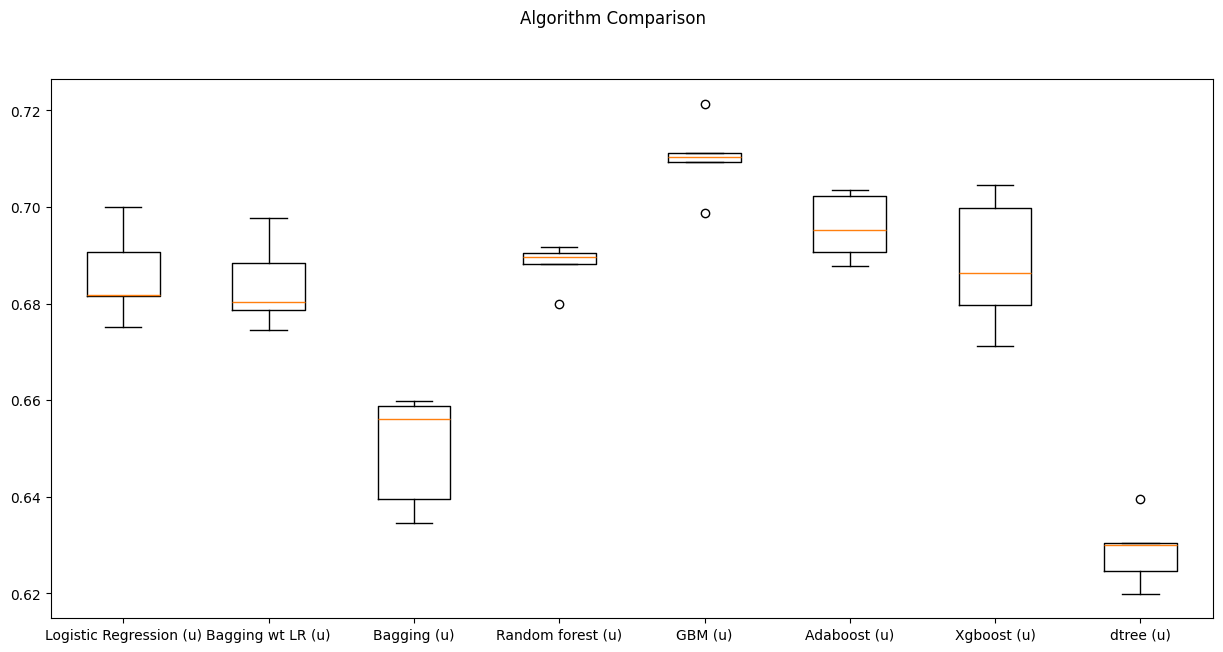

In [62]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(15, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results3)
ax.set_xticklabels(names)

plt.show()

* Again, every model's performance has dropped significantly, compared to using original data, but all models present a better performance on the validation dataset (increases from 0.043 to 0.065), probably due to smaller dataset.

* On this set GBM again has the highest perfomance with increased generalization on the validation set (difference between validation and training of 0.048 or 4.8%).

* Adaboost has the most significant increase (6.5% increase).


## Hyperparameter Tuning

### Selecting models for hyperparameter tuning

The following models will be selected for hyperparameter tuning:

* **GBM with original data**: Best overall performance with high F1 scores in both training (0.824) and validation (0.814), showing strong generalization.

* **Adaboost (u) with undersampled data**: Showed highest validation performance improvement (+0.065), indicating it benefits significantly from undersampling.

* **Random Forest (o) with oversampled data**: Best performance in training in the oversampled dataset with good generalization.

* **Xgboost with original data**: Good performance along the different datasets.


### Recommended practices and values for hyperparameter tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

### Tuning GBM with original data

In [63]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid={"n_estimators": np.arange(100,250,25), "learning_rate": [0.5, 0.2, 0.1, 0.05], "subsample":[0.5, 0.6, 0.7, 0.8], "max_features":[0.3, 0.5,"sqrt"]}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, scoring=scorer, n_iter=50, n_jobs = -2, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)## Fit the original model

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(125), 'max_features': 'sqrt', 'learning_rate': 0.05} with CV score=0.8238292054223793:
CPU times: total: 1.52 s
Wall time: 8.42 s


In [64]:
tuned_gbm = randomized_cv.best_estimator_
tuned_gbm

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",np.int64(125)
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``

In [65]:
tuned_gbm_train_perf = model_performance_classification(
    tuned_gbm, X_train, y_train
)
tuned_gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.75129,0.880467,0.776905,0.825451


In [66]:
tuned_gbm_val_perf = model_performance_classification(
    tuned_gbm, X_val, y_val
)
tuned_gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.741532,0.874401,0.769835,0.818793


### Tuning Adaboost with undersampled data

In [67]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 100, 150, 200, 250],
    "learning_rate": [0.5, 0.2, 0.05, 0.01],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -2, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un) ## Fit the model on under sampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 50, 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.71053290479589:
CPU times: total: 1.58 s
Wall time: 12.3 s


In [68]:
tuned_ada = randomized_cv.best_estimator_
tuned_ada

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...andom_state=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [69]:
tuned_ada_train_perf = model_performance_classification(tuned_ada, X_train_un, y_train_un)
tuned_ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.706314,0.749958,0.689752,0.718596


In [70]:
tuned_ada_val_perf = model_performance_classification(tuned_ada, X_val, y_val)
tuned_ada_val_perf

,Accuracy,Recall,Precision,F1
0,0.712167,0.747061,0.807529,0.776119


### Tuning Random Forest with oversampled data

In [71]:
%%time

# defining model
model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid={"n_estimators": np.arange(50,250,25), "min_samples_leaf": [2,3,4,5], "max_features":[0.1,0.3,0.5,"sqrt"], "max_samples":[0.5,0.6,0.7,0.9]}


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=5, 
    random_state=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(150), 'min_samples_leaf': 3, 'max_samples': 0.9, 'max_features': 0.5} with CV score=0.768214668716837:
CPU times: total: 5 s
Wall time: 20.2 s


In [72]:
tuned_rf = randomized_cv.best_estimator_
tuned_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",np.int64(150)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature 

In [73]:
tuned_rf_train_perf = model_performance_classification(
    tuned_rf, X_train_over, y_train_over
)
tuned_rf_train_perf

,Accuracy,Recall,Precision,F1
0,0.927768,0.918241,0.936077,0.927073


In [74]:
## Complete the code to print the model performance on the validation data.
tuned_rf_val_perf = model_performance_classification(tuned_rf,X_val, y_val)
tuned_rf_val_perf

,Accuracy,Recall,Precision,F1
0,0.711586,0.767741,0.793654,0.780482


### Tuning Xgboost with original data

In [75]:
%%time

# defining model
Model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators':[50,100,150,200,250],'subsample':[0.5,0.7,0.8,0.9], 'gamma':[0,1,3,5,7], 'colsample_bytree':[0.3,0.5,0.7], 'colsample_bylevel':[0.3,0.5,0.7]}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -2, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)## Fit the original model

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': 200, 'gamma': 5, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.7} with CV score=0.8240107578945457:
CPU times: total: 1.72 s
Wall time: 2.45 s


In [76]:
tuned_xgb = randomized_cv.best_estimator_
tuned_xgb

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.7
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [77]:
tuned_xgb_train_perf = model_performance_classification(
    tuned_xgb, X_train, y_train
)
tuned_xgb_train_perf

,Accuracy,Recall,Precision,F1
0,0.75813,0.874927,0.78682,0.828537


In [78]:
tuned_xgb_val_perf = model_performance_classification(tuned_xgb, X_val, y_val)
tuned_xgb_val_perf

,Accuracy,Recall,Precision,F1
0,0.743277,0.86896,0.774244,0.818872


## Model Performance Summary and Final Model Selection

In [79]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        tuned_gbm_train_perf.T,
        tuned_ada_train_perf.T,
        tuned_rf_train_perf.T,
        tuned_xgb_train_perf.T, 
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with original data",
    "AdaBoost tuned with undersampled data",
    "Random forest tuned with oversampled data",
    "XGBoost tuned with original data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting tuned with original data,AdaBoost tuned with undersampled data,Random forest tuned with oversampled data,XGBoost tuned with original data
Accuracy,0.751290,0.706314,0.927768,0.758130
Recall,0.880467,0.749958,0.918241,0.874927
Precision,0.776905,0.689752,0.936077,0.786820
F1,0.825451,0.718596,0.927073,0.828537


In [80]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        tuned_gbm_val_perf.T,
        tuned_ada_val_perf.T,
        tuned_rf_val_perf.T,
        tuned_xgb_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with original data",
    "AdaBoost tuned with undersampled data",
    "Random forest tuned with oversampled data",
    "XGBoost tuned with original data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with original data,AdaBoost tuned with undersampled data,Random forest tuned with oversampled data,XGBoost tuned with original data
Accuracy,0.741532,0.712167,0.711586,0.743277
Recall,0.874401,0.747061,0.767741,0.868960
Precision,0.769835,0.807529,0.793654,0.774244
F1,0.818793,0.776119,0.780482,0.818872


### Best model selection

* There are 2 models with almost identical performance: `GBM (Gradient Boosting) tuned with original data` and `XGBoost tuned with original data`.

* Both models show good F1 scores, and good generalization (differences between training and validation of less than 1%).

The selected model is: **XGBoost tuned with original data**

Criteria for selection:

* Tuned Xgboost shows the highest F1 score for the group and good generalization.
* High values for Recall and Precicion, and good balance between both.
* Decent Accuracy score.
* Is a model that can handle missing values.


### Tuning selected model with GridSearchCV

In [81]:
%%time

# Choose the type of classifier.
Model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in GridSearchCV
parameters = {'n_estimators':[150,175,200,225,250,275],'subsample':[0.6,0.7,0.8,0.9], 'gamma':[0,1,2,3,4,5,6,7,8], 'colsample_bytree':[0.3,0.5,0.6,0.7,0.8], 'colsample_bylevel':[0.3,0.5,0.6,0.7,0.8]}

# Grid of parameters from RandomizedSearchCV.
'''subsample = 0.8,
    n_estimators = 200,
    gamma = 5,
    colsample_bytree = 0.7,
    colsample_bylevel = 0.7,
    cv score = 0.8240107
    '''


# Run the grid search
grid_obj = GridSearchCV(Model, parameters, scoring=scorer, cv=5, n_jobs= -1, verbose = 2)
# verbose = 2 tells about the number of fits, which can give an idea of how long will the model take in tuning.
# n_jobs = -1 so that all CPU cores can be run parallelly to optimize the Search.

grid_obj = grid_obj.fit(X_train, y_train)

# Print the best combination of parameters.

print("Best parameters are {} with CV score={}:" .format(grid_obj.best_params_,grid_obj.best_score_))

Fitting 5 folds for each of 5400 candidates, totalling 27000 fits
Best parameters are {'colsample_bylevel': 0.8, 'colsample_bytree': 0.8, 'gamma': 5, 'n_estimators': 200, 'subsample': 0.8} with CV score=0.825860235331144:
CPU times: total: 1min 44s
Wall time: 4min 9s


In [82]:
tuned_xgb2 = grid_obj.best_estimator_
tuned_xgb2

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.8
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [83]:
tuned_xgb2_train_perf = model_performance_classification(
    tuned_xgb2, X_train, y_train
)
tuned_xgb2_train_perf

,Accuracy,Recall,Precision,F1
0,0.758298,0.874423,0.787258,0.828554


In [84]:
tuned_xgb2_val_perf = model_performance_classification(tuned_xgb2, X_val, y_val)
tuned_xgb2_val_perf

,Accuracy,Recall,Precision,F1
0,0.744294,0.867653,0.775939,0.819237


In [85]:
final_model = tuned_xgb2

### Performance of Final Model on Test Data

In [86]:
test = model_performance_classification(final_model, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.766013,0.890411,0.787197,0.835629


* Model shows strong generalization with scores higher in test dataset.
* High recall score indicates good prediction of true positives in unseen datasets.

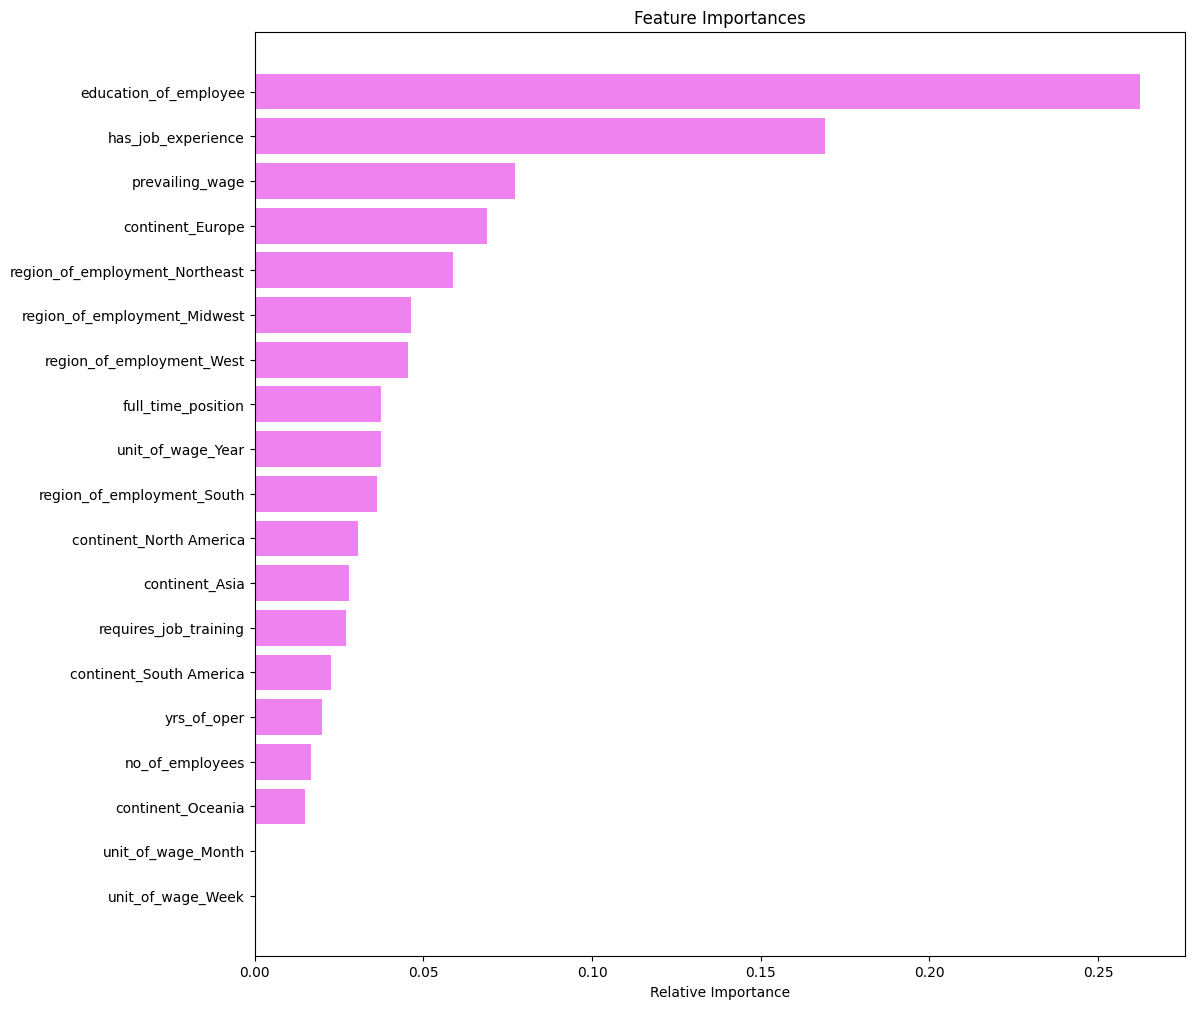

In [87]:
feature_names = X_train.columns
importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

The main factors influencing visa certification or denial are:

1. **Education**: Doctors, Masters and even Bachelors could be viewed as highly specialized workforce, not easily available locally.
2. **Job Experience**: Having no previous experience may be an indicator that the position could be better filled by local workforce.
3. **Prevailing Wages**: Positions with high wages reported annually have a better chance of being certified.
4. **Continent**: Potential employees from Europe are more likely to be certified.

### Predicting on single data points

In [88]:
# choosing 2 data points
applicant1_details = X_test.iloc[1:2, :]
applicant2_details = X_test.iloc[10:11, :]

# making a prediction
result1_prediction = final_model.predict(applicant1_details)
result2_prediction = final_model.predict(applicant2_details)

# making a prediction on probability
result1_likelihood = final_model.predict_proba(applicant1_details)
result2_likelihood = final_model.predict_proba(applicant2_details)


In [89]:
def print_results(prediction, likelihood, applicant_name):
    # Determine the label ("Certify" for 1, "Deny" for 0)
    label = "Certify" if prediction[0] == 1 else "Deny"
    
    # Get the probability for the *predicted* class
    # likelihood[0] is a list/array of probabilities, e.g., [0.2, 0.8]
    # prediction[0] is the class index (0 or 1)
    # The probability is at that index in the likelihood array
    probability = likelihood[0][prediction[0]] * 100
    
    print(f"{applicant_name} results:")
    print(f"  Prediction: {label}")
    print(f"  Probability: {probability:.2f}%")

print_results(result1_prediction, result1_likelihood, "Applicant 1")
print_results(result2_prediction, result2_likelihood, "Applicant 2")

Applicant 1 results:
  Prediction: Deny
  Probability: 51.61%
Applicant 2 results:
  Prediction: Certify
  Probability: 95.47%


## Actionable Insights and Recommendations

### Insights

Regarding the dataset:

* To reduce the big number of outliers in prevailing wages, these should be reported in a common basis, such as yearly.
* Due to change in policies regarding immigration, there could be external elements that may affect the certification process. As of January 2026 there is a list of countries with bans for immigration to the US.  The list can be verified at https://travel.state.gov/content/travel/en/News/visas-news/immigrant-visa-processing-updates-for-nationalities-at-high-risk-of-public-benefits-usage.html.  Also there was a plocamation on September 2025 regarding nonimmigrant workers that may be required to analyze: https://www.whitehouse.gov/presidential-actions/2025/09/restriction-on-entry-of-certain-nonimmigrant-workers/.

Regarding model building:

* As there are no strong predictors, and the data is bias towards "certified" (and low unbalance of 66 / 34), no significant improvement can be obtained from performing either undersampling or oversampling, as shown by the decrease in performance of all the models.
* As 2 of the models initially considered had logistic regression components, there was a need to normalize (standardize) the numeric variables. As the final model selected is XGBoost, and it is not affected by differences in scales, it can be retrained using the original non-normalized values.
* Tuning the model with GridSearchCV using some of the values obtained from RandomizedSearchCV yielded almost the same values, indicating the parameters found were very good.

Regarding applicant's profile:

* Applicants with following profile will likely get Certified:

+  1. Job experience: Has previous relevant job experience.
+  2. Education: Bachelor, Master or Doctorate degree.
+  3. Prevailing wage: Around 75000 USD per year or more.

* Other factors that may be considered for Certification:

+ - Continent: Applicants from Europe.
+ - Region: Applicants to work at Northeast, West and Midwest.
+ - Unit of Wage: Applicants with annual wages.

* Applicants with following profile will likely to be Denied:

+  1. Job experience: No previous relevant job experience.
+  2. Education: High School.
+  3. Prevailing wage: Around 65000 USD per year or less.

* Other factors that may be considered for Denial:

+ - Continent: Applicants from South America.
+ - Region: Applicants to work at Island.
+ - Unit of Wage: Applicants with Hourly wages.


### Recommendations

* To take advantage of the model's prediction probability to increase trust in results. As seen in the example, the Applicant 1 was Denied with a probability of just 51.6%, meaning that he/she had almost the same probability of being certified.
* For cases with low probability of either getting Certified or Denied, those cases can be sent to the audit process for futher investigation and analysis, as indicated in the Department of Labor Regulations, Parts 20 CFR 655 and 20 CFR 656 (https://www.ecfr.gov/current/title-20/chapter-V/part-655?toc=1, and https://www.ecfr.gov/current/title-20/chapter-V/part-656?toc=1 ).

<font size=6 color='blue'>Power Ahead</font>
___

Disclaimer: this notebook uses some of the code and structure from EasyVisa_Low_Code_Notebook.ipynb, Ensemble_Hands_On_Boosting_Notebook.ipynb and Hyperparameter_tuning_Notebook.ipynb; and some AI generated recommendations (for code) from Goggle Colab.